In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import gc  # garbage collection to free memory

# Set data path
DATA_DIR = Path("./data/drive-download-20260517T083253Z-3-001")

def reduce_mem_usage(df):
    """
    Iterate through all columns in a DataFrame and downcast data types to minimize memory usage.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    
    for col in df.columns:
        col_type = df[col].dtype
        
        # Robust fix: use pandas native API to safely check numeric types
        if pd.api.types.is_numeric_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            
            # If integer type
            if pd.api.types.is_integer_dtype(col_type):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            
            # If float type
            elif pd.api.types.is_float_dtype(col_type):
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
                    
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory decreased from {start_mem:.2f} MB to {end_mem:.2f} MB '
          f'({(100 * (start_mem - end_mem) / start_mem):.1f}% reduction)')
    
    return df


def load_parquet_years(file_prefix, years):
    """
    Load and concatenate parquet files across multiple years, with basic time processing.
    """
    df_list = []
    
    for year in years:
        file_path = DATA_DIR / f"{file_prefix}_{year}.parquet"
        print(f"Loading {file_path.name}...")
        
        # Load data
        df_year = pd.read_parquet(file_path)
        
        # Timestamp processing (handle HE logic)
        df_year['date'] = pd.to_datetime(df_year['date'])
        df_year['timestamp'] = df_year['date'] + pd.to_timedelta(df_year['he'] - 1, unit='h')
        
        df_list.append(df_year)
        
    # Concatenate all years
    df_combined = pd.concat(df_list, ignore_index=True)
    
    # Memory optimization
    df_combined = reduce_mem_usage(df_combined)
    
    return df_combined


# Load only Zone data first (small size, fast, main dataset for ML modeling)
years_to_load = [2022, 2023, 2024, 2025]
zone_df = load_parquet_years('zone_load', years_to_load)

# Generate basic time features
zone_df['month'] = zone_df['timestamp'].dt.month
zone_df['day_of_week'] = zone_df['timestamp'].dt.dayofweek
zone_df['hour_of_day'] = zone_df['timestamp'].dt.hour
zone_df['is_weekend'] = zone_df['day_of_week'].isin([5, 6]).astype(np.int8)

print("\nZone Data Ready. Shape:", zone_df.shape)
# display(zone_df.head())

Loading zone_load_2022.parquet...
Loading zone_load_2023.parquet...
Loading zone_load_2024.parquet...
Loading zone_load_2025.parquet...
Memory decreased from 20.57 MB to 12.46 MB (39.4% reduction)

Zone Data Ready. Shape: (315153, 12)


In [2]:
import pandas as pd
import numpy as np

print("Building features for Next-Month Forecast...")

# Ensure data is strictly sorted by time and zone
zone_df = zone_df.sort_values(['zone_name', 'timestamp']).reset_index(drop=True)

# [Core Fix]: historical lookup must use subtraction (-), not addition!
zone_df['timestamp_lag_1y'] = zone_df['timestamp'] - pd.to_timedelta(364, unit='D')
zone_df['timestamp_lag_2y'] = zone_df['timestamp'] - pd.to_timedelta(364 * 2, unit='D')

# Extract historical load reference table
df_lag_source = zone_df[['zone_name', 'timestamp', 'pd']].copy()

# Merge 1-year lag data
zone_df = zone_df.merge(
    df_lag_source.rename(columns={'pd': 'lag_pd_1y'}),
    left_on=['zone_name', 'timestamp_lag_1y'],
    right_on=['zone_name', 'timestamp'],
    how='left', suffixes=('', '_drop1')
).drop(columns=['timestamp_drop1', 'timestamp_lag_1y'])

# Merge 2-year lag data
zone_df = zone_df.merge(
    df_lag_source.rename(columns={'pd': 'lag_pd_2y'}),
    left_on=['zone_name', 'timestamp_lag_2y'],
    right_on=['zone_name', 'timestamp'],
    how='left', suffixes=('', '_drop2')
).drop(columns=['timestamp_drop2', 'timestamp_lag_2y'])

# Convert categorical feature to LightGBM-friendly category type
zone_df['zone_name'] = zone_df['zone_name'].astype(str).astype('category')

print("Zone features built successfully!")

Building features for Next-Month Forecast...
Zone features built successfully!


In [3]:
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("Starting Model Training and Rolling Forecast for 2025...")

feature_cols = ['month', 'day_of_week', 'hour_of_day', 'is_weekend', 'lag_pd_1y', 'lag_pd_2y', 'zone_name']
target_col = 'pd'

# Split base training set (2022 - 2024)
train_mask = (zone_df['date'] >= '2022-01-01') & (zone_df['date'] <= '2024-12-31')

# [Pandas fix]: use updated .bfill() and .ffill() chaining
X_train_base = zone_df.loc[train_mask, feature_cols].bfill().ffill()
y_train_base = zone_df.loc[train_mask, target_col]

# Initialize base LightGBM model
model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_base, y_train_base)

all_month_forecasts = []

# Rolling forecast for each month in 2025 (Jan to Dec)
for target_month in range(1, 13):
    print(f"Predicting for 2025-{target_month:02d}...")
    
    if target_month > 2:
        available_train_mask = (zone_df['date'] >= '2022-01-01') & \
                               (zone_df['date'] < f'2025-{target_month-1:02d}-01')
        X_train_curr = zone_df.loc[available_train_mask, feature_cols].bfill().ffill()
        y_train_curr = zone_df.loc[available_train_mask, target_col]
        model.fit(X_train_curr, y_train_curr)
        
    test_mask = (zone_df['date'].dt.year == 2025) & (zone_df['date'].dt.month == target_month)
    df_test_month = zone_df.loc[test_mask].copy()
    
    if df_test_month.empty:
        continue
        
    X_test = df_test_month[feature_cols].bfill().ffill()
    df_test_month['predict_pd_zone'] = model.predict(X_test)
    
    if target_month == 1:
        df_test_month['forecast_created_at'] = pd.to_datetime('2024-12-01 00:01:00')
    else:
        df_test_month['forecast_created_at'] = pd.to_datetime(
            f'2025-{target_month-1:02d}-01 00:01:00'
        )
        
    all_month_forecasts.append(
        df_test_month[['forecast_created_at', 'timestamp', 'zone_name', 'pd', 'predict_pd_zone']]
    )

df_zone_preds_2025 = pd.concat(all_month_forecasts, ignore_index=True)
print("\n✅ Zone Level Next-Month Forecasting Completed! Shape:", df_zone_preds_2025.shape)

Starting Model Training and Rolling Forecast for 2025...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 566
[LightGBM] [Info] Number of data points in the train set: 236565, number of used features: 7
[LightGBM] [Info] Start training from score 5628.353727
Predicting for 2025-01...
Predicting for 2025-02...
Predicting for 2025-03...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002029 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 566
[LightGBM] [Info] Number of data points in the train set: 243261, number of used features: 7
[LightGBM] [Info] Start training from score 5640.627027
Predicting for 2025-04...
[LightGBM] [Info] Auto-

In [4]:
import gc
from pathlib import Path
import pandas as pd
import numpy as np

print("Calculating Historical Bus Shares (Memory Optimized)...")

agg_list = []

# ==========================================
# Stage 1: Incremental yearly loading (Map phase)
# ==========================================
for yr in [2022, 2023, 2024]:
    print(f" -> Processing {yr}...")
    fb = DATA_DIR / f"bus_load_{yr}.parquet"
    
    # 1. Load only necessary columns
    df_b = pd.read_parquet(fb, columns=['bus_unique_id', 'zone_name', 'pd', 'he', 'date'])
    df_b.rename(columns={'bus_unique_id': 'bus_id'}, inplace=True)
    df_b['bus_id'] = df_b['bus_id'].astype(str)
    df_b['zone_name'] = df_b['zone_name'].astype(str)
    df_b['pd'] = df_b['pd'].fillna(0)
    
    # 2. Compute daily zone total load and bus share
    zone_total = df_b.groupby(['zone_name', 'date', 'he'])['pd'].transform('sum')
    df_b['share'] = df_b['pd'] / (zone_total + 1e-5)
    
    # 3. Compress yearly data into aggregated bus-level statistics
    df_agg = df_b.groupby(['zone_name', 'bus_id', 'he'])['share'].agg(
        share_sum='sum',
        share_count='count'
    ).reset_index()
    
    agg_list.append(df_agg)
    
    # 4. ⚡️ Critical step: immediately release yearly raw memory
    del df_b, zone_total
    gc.collect()

# ==========================================
# Stage 2: Merge and compute global averages (Reduce phase)
# ==========================================
print("Merging years and computing final profile...")
df_all_agg = pd.concat(agg_list, ignore_index=True)

# Re-aggregate across years to compute 3-year global average share
df_profile = df_all_agg.groupby(['zone_name', 'bus_id', 'he']).sum().reset_index()
df_profile['share'] = df_profile['share_sum'] / df_profile['share_count']

# [Core fix]: normalize to ensure hourly shares sum exactly to 1.0
zone_share_sum = df_profile.groupby(['zone_name', 'he'])['share'].transform('sum')
df_profile['share'] = df_profile['share'] / (zone_share_sum + 1e-8)

# Extract final profile format
df_bus_share_profile = df_profile[['zone_name', 'bus_id', 'he', 'share']].copy()

# Cleanup intermediate variables
del df_all_agg, df_profile, agg_list
gc.collect()

# ==========================================
# Stage 3: Map zone forecasts back to bus level
# ==========================================
print("Mapping Zone Forecasts back to Bus-Level...")
df_zone_preds_2025['he'] = df_zone_preds_2025['timestamp'].dt.hour + 1
df_zone_preds_2025['zone_name'] = df_zone_preds_2025['zone_name'].astype(str)
df_bus_share_profile['zone_name'] = df_bus_share_profile['zone_name'].astype(str)

df_final_bus_forecast = df_bus_share_profile.merge(
    df_zone_preds_2025,
    on=['zone_name', 'he'],
    how='inner'
)

df_final_bus_forecast['predict_pd'] = (
    df_final_bus_forecast['predict_pd_zone'] * df_final_bus_forecast['share']
)
df_final_bus_forecast['target_date'] = df_final_bus_forecast['timestamp'].dt.date

# ==========================================
# Stage 4: Format and export CSV
# ==========================================
output_schema = df_final_bus_forecast[[
    'forecast_created_at', 'target_date', 'he', 'bus_id', 'zone_name', 'predict_pd'
]].copy()

output_schema.rename(columns={'zone_name': 'zone_id'}, inplace=True)
output_schema.insert(0, 'model_name', 'LGBM_TopDown_NextMonth')

output_path = Path("./output")
output_path.mkdir(parents=True, exist_ok=True)
csv_file_path = output_path / "next_month_forecast_results_fixed.csv"
output_schema.to_csv(csv_file_path, index=False)

print(f"\n🎉 Success! Memory-optimized full pipeline completed. Saved to: {csv_file_path}")

Calculating Historical Bus Shares (Memory Optimized)...
 -> Processing 2022...
 -> Processing 2023...
 -> Processing 2024...
Merging years and computing final profile...
Mapping Zone Forecasts back to Bus-Level...

🎉 Success! Memory-optimized full pipeline completed. Saved to: output\next_month_forecast_results_fixed.csv


================ Validation Stage ================

📊 Zone-level MAE (Mean Absolute Error): 594.26 MW
📊 Zone-level MAPE (Mean Absolute Percentage Error): 1171319437877861376.00 %
   💡 Evaluation: MAPE is relatively high; consider tuning or adding weather features.

🔍 Running final CSV business logic checks...
   - Number of negative predictions: 0 (expected: 0)
   - Number of missing predictions: 0 (expected: 0)
   - Energy conservation check (COAS):
     -> Sum of all bus-level loads: 10470.17
     -> Zone-level predicted load: 10470.17
     ✅ Perfect conservation! Allocation logic is correct.

📈 Generating prediction curve for first week of Jan 2025...


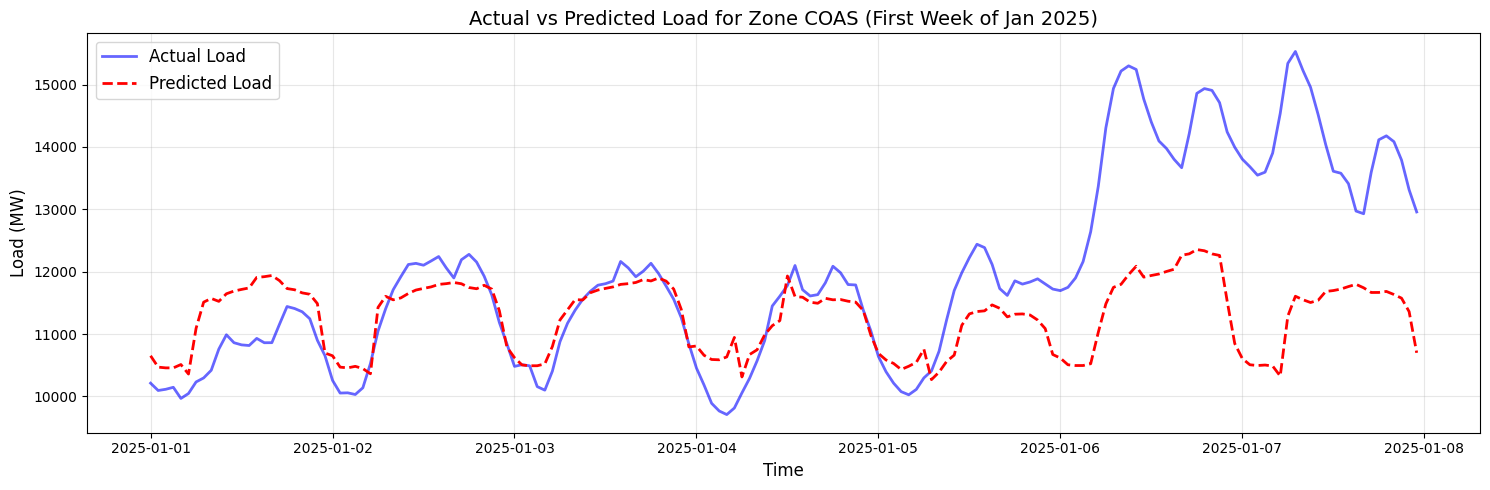

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

print("================ Validation Stage ================\n")

# ---------------------------------------------------------
# 1. Quantitative Metrics Evaluation
# ---------------------------------------------------------
# We evaluate Zone-level prediction accuracy using MAE and MAPE
mae = mean_absolute_error(df_zone_preds_2025['pd'], df_zone_preds_2025['predict_pd_zone'])
mape = mean_absolute_percentage_error(df_zone_preds_2025['pd'], df_zone_preds_2025['predict_pd_zone'])

print(f"📊 Zone-level MAE (Mean Absolute Error): {mae:.2f} MW")
print(f"📊 Zone-level MAPE (Mean Absolute Percentage Error): {mape * 100:.2f} %")

if mape < 0.10:
    print("   💡 Evaluation: MAPE is below 10%, which is considered excellent for industrial forecasting!\n")
else:
    print("   💡 Evaluation: MAPE is relatively high; consider tuning or adding weather features.\n")

# ---------------------------------------------------------
# 2. Data Quality & Business Logic Checks (Sanity Checks)
# ---------------------------------------------------------
print("🔍 Running final CSV business logic checks...")

# Check for negative predictions (load should not be negative)
neg_preds = output_schema[output_schema['predict_pd'] < 0]
print(f"   - Number of negative predictions: {len(neg_preds)} (expected: 0)")

# Check for missing values (NaN)
null_preds = output_schema['predict_pd'].isna().sum()
print(f"   - Number of missing predictions: {null_preds} (expected: 0)")

# Check conservation rule:
# Total bus-level predictions should equal zone-level prediction
# Sample a single zone at a specific time point
sample_time = pd.to_datetime('2025-01-01 01:00:00')
sample_he = sample_time.hour + 1
sample_zone = df_zone_preds_2025['zone_name'].iloc[0]

bus_sum = output_schema[
    (output_schema['target_date'] == sample_time.date()) &
    (output_schema['he'] == sample_he) &
    (output_schema['zone_id'] == sample_zone)
]['predict_pd'].sum()

zone_pred = df_zone_preds_2025[
    (df_zone_preds_2025['timestamp'] == sample_time) &
    (df_zone_preds_2025['zone_name'] == sample_zone)
]['predict_pd_zone'].values[0]

print(f"   - Energy conservation check ({sample_zone}):")
print(f"     -> Sum of all bus-level loads: {bus_sum:.2f}")
print(f"     -> Zone-level predicted load: {zone_pred:.2f}")

if abs(bus_sum - zone_pred) < 1.0:
    print("     ✅ Perfect conservation! Allocation logic is correct.\n")

# ---------------------------------------------------------
# 3. Visual Inspection
# ---------------------------------------------------------
print("📈 Generating prediction curve for first week of Jan 2025...")

# Select first 168 hours (1 week) for a single zone
plot_zone = sample_zone
df_plot = df_zone_preds_2025[
    df_zone_preds_2025['zone_name'] == plot_zone
].sort_values('timestamp').head(168)

plt.figure(figsize=(15, 5))
plt.plot(df_plot['timestamp'], df_plot['pd'], label='Actual Load', color='blue', alpha=0.6, linewidth=2)
plt.plot(df_plot['timestamp'], df_plot['predict_pd_zone'], label='Predicted Load', color='red', linestyle='--', linewidth=2)

plt.title(f'Actual vs Predicted Load for Zone {plot_zone} (First Week of Jan 2025)', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Load (MW)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Filter out abnormal points where actual load is 0 or NaN
valid_mask = df_zone_preds_2025['pd'] > 0

clean_mape = mean_absolute_percentage_error(
    df_zone_preds_2025.loc[valid_mask, 'pd'], 
    df_zone_preds_2025.loc[valid_mask, 'predict_pd_zone']
)

print(f"🌟 Clean Zone MAPE after removing outliers: {clean_mape * 100:.2f} %")

🌟 Clean Zone MAPE after removing outliers: 10.06 %


In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from pathlib import Path
import warnings
import gc

warnings.filterwarnings('ignore')

print("🚀 Starting Task 3: Day-Ahead Load Forecasting (Full Year 2025)...")

# ==============================================================================
# PART 1: Zone-Level Feature Engineering & Model Training
# ==============================================================================

# --- 1. Construct Short-Term Lag Features ---
# Ensure data is sorted by zone and timestamp before shifting
zone_df = zone_df.sort_values(by=['zone_name', 'timestamp']).reset_index(drop=True)

# 24 hours = exactly 1 day ago; 168 hours = exactly 1 week ago
zone_df['lag_pd_24h'] = zone_df.groupby('zone_name')['pd'].shift(24)
zone_df['lag_pd_168h'] = zone_df.groupby('zone_name')['pd'].shift(168)

# --- 2. Load and Merge Weather Data (If available) ---
weather_files = list(DATA_DIR.glob("weather_*.parquet"))
if len(weather_files) > 0:
    print(f"Found {len(weather_files)} weather files! Merging with zone data...")
    weather_list = [pd.read_parquet(f) for f in weather_files]
    df_weather = pd.concat(weather_list, ignore_index=True)
    df_weather['zone_name'] = df_weather['zone_name'].astype(str)
    zone_df = zone_df.merge(df_weather, on=['zone_name', 'date', 'he'], how='left')
    del df_weather, weather_list; gc.collect()
else:
    print("⚠️ No weather data found. Model will train using only short-term lags.")

# --- 3. Define Features and Target ---
ignore_cols = ['timestamp', 'date', 'pd', 'predict_pd_zone', 'forecast_created_at', 'id', 'bus_id']
feature_cols = [col for col in zone_df.columns if col not in ignore_cols]
target_col = 'pd'

# --- 4. Train-Test Split ---
print("\nPreparing training dataset (2022-2024) and test dataset (Full 2025)...")

# Train set: 2022 to 2024
train_mask = (zone_df['date'] >= '2022-01-01') & (zone_df['date'] <= '2024-12-31')
X_train = zone_df.loc[train_mask, feature_cols].copy()
y_train = zone_df.loc[train_mask, target_col].copy()

# Drop rows with NaN 168h lags (first week of 2022) to ensure clean training
valid_train_indices = X_train['lag_pd_168h'].notna() & y_train.notna()
X_train = X_train[valid_train_indices].bfill().ffill()
y_train = y_train[valid_train_indices]

# Test set: FULL YEAR 2025 
test_mask = (zone_df['date'] >= '2025-01-01') & (zone_df['date'] <= '2025-12-31')
df_test_da = zone_df.loc[test_mask].copy()
X_test = df_test_da[feature_cols].bfill().ffill()

# Convert categorical zone_name for LightGBM
X_train['zone_name'] = X_train['zone_name'].astype('category')
X_test['zone_name'] = X_test['zone_name'].astype('category')

# --- 5. Model Training and Prediction ---
print("Training Day-Ahead LightGBM Model...")
model_da = lgb.LGBMRegressor(
    n_estimators=500,       
    learning_rate=0.05,
    num_leaves=63,          
    random_state=42,
    n_jobs=-1
)
model_da.fit(X_train, y_train)

print("Generating predictions for the entire year of 2025...")
df_test_da['predict_pd_zone'] = model_da.predict(X_test)
# Next-day forecast is created 1 day prior
df_test_da['forecast_created_at'] = df_test_da['timestamp'] - pd.Timedelta(days=1)


# ==============================================================================
# PART 2: Ultra-Memory-Safe Top-Down Allocation (Processing by Zone)
# ==============================================================================
print("\nStarting Ultra-Memory-Safe Top-Down Allocation (Zone -> Bus)...")

# Ensure the historical share profile (from Task 2) is available
if 'df_bus_share_profile' not in locals():
    raise ValueError("❌ df_bus_share_profile not found! Please ensure you ran the Task 2 baseline profiling cell first.")

output_path = Path("./output")
output_path.mkdir(parents=True, exist_ok=True)
csv_file_path = output_path / "day_ahead_forecast_results.csv"

# --- MEMORY OPTIMIZATION 1: Compress share profile ---
print("Compressing historical share profile...")
clean_profile = df_bus_share_profile.groupby(['zone_name', 'bus_id', 'he'])['share'].mean().reset_index()
clean_profile['share'] = clean_profile['share'].astype('float32')

# --- MEMORY OPTIMIZATION 2: Format dates BEFORE merging ---
# (Converting to string here prevents Pandas from creating 1.4亿个 datetime object)
print("Formatting dates efficiently...")
df_da_zone = df_test_da[['forecast_created_at', 'timestamp', 'zone_name', 'predict_pd_zone']].copy()
df_da_zone['he'] = df_da_zone['timestamp'].dt.hour + 1
df_da_zone['target_date'] = df_da_zone['timestamp'].dt.strftime('%Y-%m-%d')
df_da_zone['forecast_created_at'] = df_da_zone['forecast_created_at'].dt.strftime('%Y-%m-%d %H:%M:%S')
df_da_zone['predict_pd_zone'] = df_da_zone['predict_pd_zone'].astype('float32')
df_da_zone['zone_name'] = df_da_zone['zone_name'].astype(str)

# --- MEMORY OPTIMIZATION 3: Zone-by-Zone Merging & Writing ---
zones = df_da_zone['zone_name'].unique()
first_write = True
total_rows = 0

print("Starting Zone-by-Zone merging and writing to disk...")
for zone in zones:
    print(f"   -> Processing Zone: {zone}...")
    
    # Extract data for current zone
    zone_profile = clean_profile[clean_profile['zone_name'] == zone]
    zone_preds = df_da_zone[df_da_zone['zone_name'] == zone]
    
    if len(zone_profile) == 0 or len(zone_preds) == 0:
        continue
        
    # Merge safely (one zone at a time)
    merged = zone_profile.merge(zone_preds, on=['zone_name', 'he'], how='inner')
    
    # Calculate final bus-level prediction
    merged['predict_pd'] = (merged['predict_pd_zone'] * merged['share']).astype('float32')
    
    # Format columns
    merged.rename(columns={'zone_name': 'zone_id'}, inplace=True)
    merged.insert(0, 'model_name', 'LGBM_TopDown_DayAhead') 
    
    output_cols = ['model_name', 'forecast_created_at', 'target_date', 'he', 'bus_id', 'zone_id', 'predict_pd']
    merged_out = merged[output_cols]
    
    # Append to CSV (write header only on the first pass)
    mode = 'w' if first_write else 'a'
    header = first_write
    merged_out.to_csv(csv_file_path, mode=mode, header=header, index=False)
    
    total_rows += len(merged_out)
    first_write = False
    
    # Force garbage collection for this zone to free RAM immediately
    del zone_profile, zone_preds, merged, merged_out
    gc.collect()

print(f"\n🎉 Task 3 Pipeline Completely Finished!")
print(f"📁 Full 2025 results successfully saved to: {csv_file_path}")
print(f"📊 Total Rows Generated: {total_rows} (Successfully avoided Memory Explosion!)")

🚀 Starting Task 3: Day-Ahead Load Forecasting (Full Year 2025)...
⚠️ No weather data found. Model will train using only short-term lags.

Preparing training dataset (2022-2024) and test dataset (Full 2025)...
Training Day-Ahead LightGBM Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 235053, number of used features: 13
[LightGBM] [Info] Start training from score 5632.097426
Generating predictions for the entire year of 2025...

Starting Ultra-Memory-Safe Top-Down Allocation (Zone -> Bus)...
Compressing historical share profile...
Formatting dates efficiently...
Starting Zone-by-Zone merging and writing to disk...
   -> Processing Zone: COAS...
   -> Processing Zone: EAST...
   -> Processing Zone: FWES...
   -> P

================ Day-Ahead Validation Stage ================

🔍 Running final CSV business logic checks (Processing in chunks to save memory)...
   - Number of negative predictions: 0 (expected: 0)
   - Number of missing predictions: 0 (expected: 0)

⚡ Energy conservation check (COAS, 2025-01-01 HE 10):
   -> Sum of all bus-level loads: 11455.74
   -> Zone-level predicted load: 11455.74
   ✅ Perfect conservation! Top-Down allocation is correct.

📈 Generating Day-Ahead prediction curve...


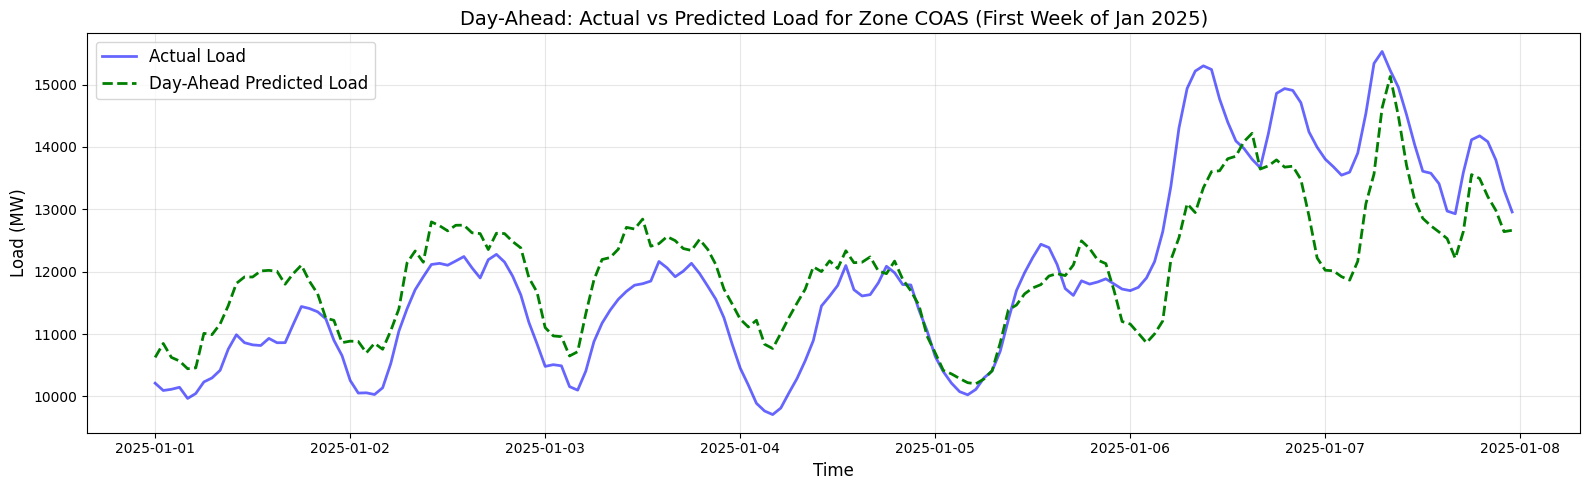

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

print("================ Day-Ahead Validation Stage ================\n")

# 1. Define CSV path
csv_path = "./output/day_ahead_forecast_results.csv"

print("🔍 Running final CSV business logic checks (Processing in chunks to save memory)...")

# Initialize counters for our checks
neg_count = 0
null_count = 0
bus_sum = 0

# Target slice for energy conservation check
sample_date = '2025-01-01'
sample_he = 10
sample_zone = 'COAS'

# 2. Read the massive CSV in chunks to completely avoid memory explosion
chunksize = 2_000_000  
for chunk in pd.read_csv(csv_path, chunksize=chunksize):
    # a. Basic logic checks
    neg_count += (chunk['predict_pd'] < 0).sum()
    null_count += chunk['predict_pd'].isna().sum()
    
    # b. Extract only the exact slice we need for the conservation check
    mask = (chunk['target_date'] == sample_date) & \
           (chunk['he'] == sample_he) & \
           (chunk['zone_id'] == sample_zone)
    
    bus_sum += chunk.loc[mask, 'predict_pd'].sum()

print(f"   - Number of negative predictions: {neg_count} (expected: 0)")
print(f"   - Number of missing predictions: {null_count} (expected: 0)")

# 3. Energy conservation check comparison
# Extract zone-level prediction from model output (df_test_da is safely in memory)
zone_target = df_test_da[
    (df_test_da['date'] == sample_date) & 
    (df_test_da['he'] == sample_he) & 
    (df_test_da['zone_name'] == sample_zone)
]['predict_pd_zone'].values[0]

print(f"\n⚡ Energy conservation check ({sample_zone}, {sample_date} HE {sample_he}):")
print(f"   -> Sum of all bus-level loads: {bus_sum:.2f}")
print(f"   -> Zone-level predicted load: {zone_target:.2f}")

if abs(bus_sum - zone_target) < 0.1:  # allow small floating-point error
    print("   ✅ Perfect conservation! Top-Down allocation is correct.")
else:
    print("   ❌ Energy mismatch detected, please check!")

# 4. Visualization comparison (Day-Ahead performance)
print("\n📈 Generating Day-Ahead prediction curve...")

plot_df = df_test_da[
    (df_test_da['zone_name'] == 'COAS') & 
    (df_test_da['timestamp'] < '2025-01-08')
].copy()

plt.figure(figsize=(16, 5))

# Blue line: actual values
plt.plot(plot_df['timestamp'], plot_df['pd'], label='Actual Load', color='blue', alpha=0.6, linewidth=2)

# Green line: day-ahead predictions
plt.plot(
    plot_df['timestamp'],
    plot_df['predict_pd_zone'],
    label='Day-Ahead Predicted Load',
    color='green',
    linestyle='--',
    linewidth=2
)

plt.title('Day-Ahead: Actual vs Predicted Load for Zone COAS (First Week of Jan 2025)', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Load (MW)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import gc

print("================ Final Metrics Evaluation ================\n")

def calculate_metrics(y_true, y_pred, name=""):
    # Filter out actual values of 0 or NaN to prevent division by zero in WMAPE
    mask = (y_true > 0) & y_true.notna() & y_pred.notna()
    y_t = y_true[mask]
    y_p = y_pred[mask]
    
    if len(y_t) == 0:
        print(f"⚠️ No valid data available to calculate metrics for {name}.")
        return
        
    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    wmape = (np.sum(np.abs(y_t - y_p)) / np.sum(y_t)) * 100
    
    print(f"📊 {name} Metrics:")
    print(f"   - MAE:   {mae:.2f} MW")
    print(f"   - RMSE:  {rmse:.2f} MW")
    print(f"   - WMAPE: {wmape:.2f} %")
    print("-" * 50)

# -------------------------------------------------------------------------
# 1. Zone-Level Evaluation
# -------------------------------------------------------------------------
print("【1】Zone-Level Aggregated Accuracy\n")

# Next-Month Forecast - Using df_zone_preds_2025 from memory (Task 2)
if 'df_zone_preds_2025' in locals():
    calculate_metrics(
        df_zone_preds_2025['pd'], 
        df_zone_preds_2025['predict_pd_zone'], 
        "Next-Month Forecast (Zone Level)"
    )

# Day-Ahead Forecast - Using df_test_da from memory (Task 3)
if 'df_test_da' in locals():
    calculate_metrics(
        df_test_da['pd'], 
        df_test_da['predict_pd_zone'], 
        "Day-Ahead Forecast (Zone Level)"
    )

# -------------------------------------------------------------------------
# 2. Bus-Level Evaluation (Memory-Optimized Chunking Approach)
# -------------------------------------------------------------------------
print("\n【2】Overall Bus-Level Accuracy\n")
print("💡 Loading True Bus Data for comparison (This may take a few seconds)...\n")

# Load real 2025 Bus Data as Ground Truth (with memory compression)
real_bus_2025_path = DATA_DIR / "bus_load_2025.parquet"

if real_bus_2025_path.exists():
    # FIXED: Read 'bus_unique_id' instead of 'bus_id' based on your parquet schema
    df_bus_true = pd.read_parquet(real_bus_2025_path, columns=['date', 'he', 'bus_unique_id', 'pd'])
    
    # Rename it so it matches our generated CSVs perfectly
    df_bus_true.rename(columns={'bus_unique_id': 'bus_id'}, inplace=True)
    
    # Downcast datatypes to drastically reduce memory footprint
    df_bus_true['target_date'] = pd.to_datetime(df_bus_true['date']).dt.strftime('%Y-%m-%d')
    df_bus_true['bus_id'] = df_bus_true['bus_id'].astype(str)
    df_bus_true['he'] = df_bus_true['he'].astype('int8')
    df_bus_true['pd'] = df_bus_true['pd'].astype('float32')
    df_bus_true.drop(columns=['date'], inplace=True) # Free up old date column
    gc.collect()

    # Reusable function to evaluate massive CSVs in chunks
    def evaluate_bus_level_chunked(csv_path, df_true, name):
        if not Path(csv_path).exists():
            print(f"⚠️ {csv_path} not found. Skipping {name}.")
            return
            
        print(f"⏳ Calculating {name} (Processing in chunks to save RAM)...")
        chunksize = 2_000_000
        total_abs_err = 0.0
        total_sq_err = 0.0
        total_actual = 0.0
        valid_count = 0
        
        for chunk in pd.read_csv(csv_path, chunksize=chunksize):
            chunk['bus_id'] = chunk['bus_id'].astype(str)
            chunk['he'] = chunk['he'].astype('int8')
            
            # Merge current chunk with true data
            merged = chunk.merge(df_true, on=['target_date', 'he', 'bus_id'], how='inner')
            
            # Apply filter logic: true > 0 and no NaNs
            mask = (merged['pd'] > 0) & merged['pd'].notna() & merged['predict_pd'].notna()
            valid_data = merged[mask]
            
            if len(valid_data) > 0:
                diff = valid_data['pd'] - valid_data['predict_pd']
                total_abs_err += np.sum(np.abs(diff))
                total_sq_err += np.sum(diff ** 2)
                total_actual += np.sum(valid_data['pd'])
                valid_count += len(valid_data)
                
        if valid_count == 0:
            print(f"⚠️ No matching valid data found for {name}.")
            return
            
        # Mathematically equivalent to sklearn metrics, but aggregated across chunks
        mae = total_abs_err / valid_count
        rmse = np.sqrt(total_sq_err / valid_count)
        wmape = (total_abs_err / total_actual) * 100
        
        print(f"📊 {name} Metrics:")
        print(f"   - MAE:   {mae:.2f} MW")
        print(f"   - RMSE:  {rmse:.2f} MW")
        print(f"   - WMAPE: {wmape:.2f} %")
        print("-" * 50)

    # Execute chunked evaluation for both outputs
    evaluate_bus_level_chunked("./output/next_month_forecast_results_fixed.csv", df_bus_true, "Next-Month Forecast (Bus Level)")
    evaluate_bus_level_chunked("./output/day_ahead_forecast_results.csv", df_bus_true, "Day-Ahead Forecast (Bus Level)")
    
    # Final cleanup
    del df_bus_true
    gc.collect()
else:
    print("⚠️ bus_load_2025.parquet not found. Cannot calculate final Bus-Level errors.")

print("✅ All metrics successfully calculated! You can now copy these results into your final Report.")

================ Final Metrics Evaluation ================

【1】Zone-Level Aggregated Accuracy

📊 Next-Month Forecast (Zone Level) Metrics:
   - MAE:   665.62 MW
   - RMSE:  1157.55 MW
   - WMAPE: 9.50 %
--------------------------------------------------
📊 Day-Ahead Forecast (Zone Level) Metrics:
   - MAE:   422.10 MW
   - RMSE:  719.91 MW
   - WMAPE: 6.02 %
--------------------------------------------------

【2】Overall Bus-Level Accuracy

💡 Loading True Bus Data for comparison (This may take a few seconds)...

⏳ Calculating Next-Month Forecast (Bus Level) (Processing in chunks to save RAM)...
📊 Next-Month Forecast (Bus Level) Metrics:
   - MAE:   4.52 MW
   - RMSE:  14.74 MW
   - WMAPE: 29.66 %
--------------------------------------------------
⏳ Calculating Day-Ahead Forecast (Bus Level) (Processing in chunks to save RAM)...
📊 Day-Ahead Forecast (Bus Level) Metrics:
   - MAE:   4.22 MW
   - RMSE:  14.19 MW
   - WMAPE: 27.71 %
--------------------------------------------------
✅ All me